In [1]:

# basic stuff
import torch
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np
from collections import OrderedDict

# tsl
from tsl.data import SpatioTemporalDataset
from tsl.data.datamodule import (SpatioTemporalDataModule,
                                 TemporalSplitter)
from tsl.data.preprocessing import StandardScaler
from tsl.metrics.torch import MaskedMAE, MaskedMAPE
from tsl.engines import Predictor

# pytorch lightning
from pytorch_lightning.loggers import TensorBoardLogger
import pytorch_lightning as ptl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping


# architecture from paper
from lib.nn.encoders.corel_encoder import CoRelEncoder
from lib.nn.decoder.base_decoder import BaseDecoder
from lib.nn.encoder_decoder_model import EncoderDecoderModel

# reproducibility
ptl.seed_everything(42)


Seed set to 42


42

In [14]:
df = pd.read_csv('../data/EWZ_cleaned.csv', index_col=0)

torch_dataset_hour_forecast = SpatioTemporalDataset(target=df,
                                      horizon=4,
                                      window=4 * 24,
                                      stride=1)


# Normalize data using mean and std computed over time and node dimensions
scalers = {'target': StandardScaler(axis=(0, 1))}

# Split data sequentially:
splitter = TemporalSplitter(val_len=0.1, test_len=0.25)

dm = SpatioTemporalDataModule(
    dataset=torch_dataset_hour_forecast,
    scalers=scalers,
    splitter=splitter,
    batch_size=64,
)

input_size = torch_dataset_hour_forecast.n_channels  
n_nodes = torch_dataset_hour_forecast.n_nodes        
horizon = torch_dataset_hour_forecast.horizon 

### Train with best hyperparams

In [4]:
with open("./best_hyperparams_hour_forecast_no_lstm.json", "r") as f:
            best_params = json.load(f)

In [4]:
def print_model_size(model):
    tot = sum([p.numel() for p in model.parameters() if p.requires_grad])
    out = f"Number of model ({model.__class__.__name__}) parameters:{tot:10d}"
    print("=" * len(out))
    print(out)

stgnn = EncoderDecoderModel(
    input_size=input_size,
    output_size=input_size,
    horizon=horizon,
    encoder_class=CoRelEncoder,
    encoder_kwargs={'gnn_layers': best_params['spatial_layers'], 'temporal_layers': best_params['temporal_layers'],
                    'hidden_size': best_params['hidden_dim'], 'n_instances': n_nodes, 'emb_size': best_params['hidden_dim'],
                    'n_neighbors':best_params['k'], 'conv_type': best_params['conv_type'], 'temporal_type':'gru'},
    decoder_class=BaseDecoder,
    decoder_kwargs={},
    exog_size= 0,
)


print_model_size(stgnn)

Number of model (EncoderDecoderModel) parameters:     92070


In [6]:
logger = TensorBoardLogger(save_dir="logs", name="train_hour_forecast_no_lstm", version=0)

loss_fn = MaskedMAE()

metrics = {'mae': MaskedMAE()}

# setup predictor
predictor = Predictor(
    model=stgnn,
    optim_class=torch.optim.Adam,
    optim_kwargs={'lr': best_params['learning_rate']},
    loss_fn=loss_fn,
    metrics=metrics
)

In [8]:
checkpoint_callback = ModelCheckpoint(
    dirpath='logs',
    save_top_k=1,
    monitor='val_mae',
    mode='min',
)

trainer = ptl.Trainer(max_epochs=20,
                     logger=logger,
                     limit_train_batches=10,  # end an epoch after 10 updates
                     callbacks=[checkpoint_callback])

trainer.fit(predictor, datamodule=dm)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



  | Name          | Type                | Params | Mode
-------------------------------------------------------------
0 | loss_fn       | MaskedMAE           | 0      | eval
1 | train_metrics | MetricCollection    | 0      | eval
2 | val_metrics   | MetricCollection    | 0      | eval
3 | test_metrics  | MetricCollection    | 0      | eval
4 | model         | EncoderDecoderModel | 92.1 K | eval
-------------------------------------------------------------
92.1 K    Trainable params
0         Non-trainable params
92.1 K    Total params
0.368     Total estimated model params size (MB)
0         Modules in train mode
26        Modules in eval mode


c:\Users\matya\OneDrive\Bureau\Semester_project\SemesterProject\venv\lib\site-packages\pytorch_lightning\loops\fit_loop.py:527: Found 27 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Epoch 19: 100%|██████████| 10/10 [03:19<00:00,  0.05it/s, v_num=0, val_mae=0.0022, train_mae=0.00393] 

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 10/10 [03:19<00:00,  0.05it/s, v_num=0, val_mae=0.0022, train_mae=0.00393]


### Load trainer model

In [5]:
model = EncoderDecoderModel(
    input_size=input_size,
    output_size=input_size,
    horizon=horizon,
    encoder_class=CoRelEncoder,
    encoder_kwargs={'gnn_layers': best_params['spatial_layers'], 'temporal_layers': best_params['temporal_layers'],
                    'hidden_size': best_params['hidden_dim'], 'n_instances': n_nodes, 'emb_size': best_params['hidden_dim'],
                    'n_neighbors':best_params['k'], 'conv_type': best_params['conv_type'], 'temporal_type':'gru'},
    decoder_class=BaseDecoder,
    decoder_kwargs={},
    exog_size= 0,
)

checkpoint = torch.load("./logs/epoch=13-step=140.ckpt", weights_only=False)
state_dict = checkpoint["state_dict"]

# fix error with 'model.' prefix
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    new_key = k.replace("model.", "") 
    new_state_dict[new_key] = v

model.load_state_dict(new_state_dict, strict=True)
model.eval()

EncoderDecoderModel(
  (encoder): CoRelEncoder(
    (emb): NodeEmbedding(n_nodes=83, embedding_size=64)
    (input_encoder): Linear(in_features=65, out_features=64, bias=True)
    (temporal_encoder): RNN(
      (rnn): GRU(64, 64, num_layers=2)
    )
    (gnn_layers): ModuleList(
      (0-1): 2 x DiffConv(64, 64)
    )
    (graph_learning_module): DifferentiableKnnGraphLayer(
      (sampler): StraightThroughSubsetSampler()
      (logits): AdjEmb()
    )
  )
  (decoder): BaseDecoder(
    (decoder): Linear(in_features=192, out_features=4, bias=True)
    (rearrange): Rearrange('b n (t f) -> b t n f', t=4)
  )
)

### Plot prediction on test set

In [47]:
df_test = pd.read_csv('../data/EWZ_test.csv', index_col=0)


torch_dataset_test = SpatioTemporalDataset(target=df_test,
                                      horizon=4,
                                      window=4 * 24,
                                      stride=1)



In [48]:
# TODO: rescale predictions


cols = df_test.columns
col_idx = 0

n_pred = 500

preds = np.zeros(n_pred)

for i in range(n_pred):
    preds[i] = model(torch_dataset_test[i].input.x.unsqueeze(0))[0,0,col_idx, 0]
    torch.cuda.empty_cache()




truth = [torch_dataset_test[i].input.x.unsqueeze(0)[0,0,col_idx, 0] for i in range(n_pred)]


c:\Users\matya\OneDrive\Bureau\Semester_project\SemesterProject\src\lib\nn\utils.py:12: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:322.)
  emb = emb[[None] * (x.ndim - emb.ndim)]
C:\Users\matya\AppData\Local\Temp\ipykernel_13056\4041651342.py:12: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  preds[i] = model(torch_dataset_test[i].input.x.unsqueeze(0))[0,0,col_idx, 0]
C:\Users\matya\AppData\

In [ ]:
scaler = dm.scalers['target']

# preds_scaled = scaler.inverse_transform(torch.tensor(preds.reshape(-1, 1))).numpy().flatten()

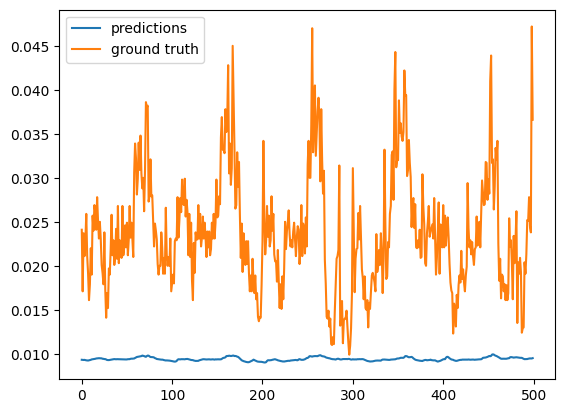

In [ ]:
plt.plot(range(n_pred), preds, label='predictions')
plt.plot(range(n_pred), truth, label='ground truth')
plt.legend()